## 基礎題 - 算出斜率w與截距b

y = wx + b

記得計算前X須符合資料格式
$$[x_1, x_2, \ldots, x_{50}]$$

==> 

$$[[x_1], [x_2], \ldots, [x_{50}]]$$

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
        1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
        2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
        3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
        4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
        5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
        6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
        7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
        8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
        9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ])
y = np.array([ 0.85848224, -0.10657947,  1.42771901,  0.53554778,  1.20216826,
        1.81330509,  1.88362644,  2.23557653,  2.7384889 ,  3.41174583,
        4.08573636,  3.82529502,  4.39723111,  4.8852381 ,  4.70092778,
        4.66993962,  6.05133235,  5.44529881,  7.22571332,  6.79423911,
        7.05424438,  7.00413058,  7.98149596,  7.00044008,  7.95903855,
        9.96125238,  9.06040794,  9.56018295,  9.30035956,  9.26517614,
        9.56401824, 10.07659844, 11.56755942, 11.38956185, 11.83586027,
       12.45642786, 11.58403954, 11.60186428, 13.88486667, 13.35550112,
       13.93938726, 13.31678277, 13.69551472, 14.76548676, 14.81731598,
       14.9659187 , 15.19213921, 15.28195017, 15.97997265, 16.41258817])

In [3]:
# ??? sklearn.linear_model ????? LinearRegression ??
from sklearn.linear_model import LinearRegression

# ??????????????
model = LinearRegression()

# ???? x ??? 1D -> 2D
X = x.reshape(-1, 1)

# ? x, y ???? LinearRegression ??????
model.fit(X, y)

# ????????????????
print('Coefficients: ', model.coef_)
print('interception: ', model.intercept_)


Coefficients:  [1.61701852]
interception:  0.2731296894942137


## 進階題 - 切割資料集分別做訓練與預測(訓練資料80%、測試資料20%)


In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x = np.array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
        1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
        2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
        3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
        4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
        5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
        6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
        7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
        8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
        9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ])
y = np.array([ 0.85848224, -0.10657947,  1.42771901,  0.53554778,  1.20216826,
        1.81330509,  1.88362644,  2.23557653,  2.7384889 ,  3.41174583,
        4.08573636,  3.82529502,  4.39723111,  4.8852381 ,  4.70092778,
        4.66993962,  6.05133235,  5.44529881,  7.22571332,  6.79423911,
        7.05424438,  7.00413058,  7.98149596,  7.00044008,  7.95903855,
        9.96125238,  9.06040794,  9.56018295,  9.30035956,  9.26517614,
        9.56401824, 10.07659844, 11.56755942, 11.38956185, 11.83586027,
       12.45642786, 11.58403954, 11.60186428, 13.88486667, 13.35550112,
       13.93938726, 13.31678277, 13.69551472, 14.76548676, 14.81731598,
       14.9659187 , 15.19213921, 15.28195017, 15.97997265, 16.41258817])


Text(0.5, 1.0, 'Training Data')

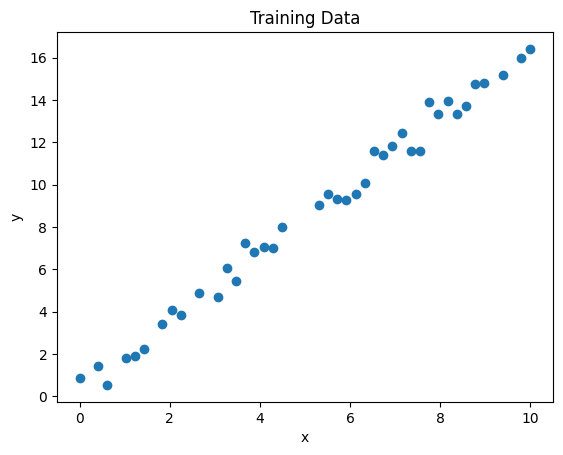

In [5]:
# ??? sklearn.linear_model ????? LinearRegression ??
from sklearn.linear_model import LinearRegression

# ??? sklearn.model_selection ????? train_test_split ??
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ?????(????80%?????20%???random_state=20)
X = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

# ???????? matplotlib ??
plt.scatter(X_train.ravel(), y_train)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data')


## 用訓練資料來 fit 函數
1. 只用訓練資料集的資料進行linear regression演算法<br>
2. 並計算出訓練階段的MSE
3. 畫出目標點(藍色)與預測點(紅色)的對應圖
![](images/LR_train.PNG)

In [6]:
# ???????????? linear regression ???
regr = LinearRegression()
regr.fit(X_train, y_train)

print('Coefficients: ', regr.coef_)
print('interception: ', regr.intercept_)


Coefficients:  [1.60659227]
interception:  0.36802581786862376


Train MSE = 0.2284495300761316


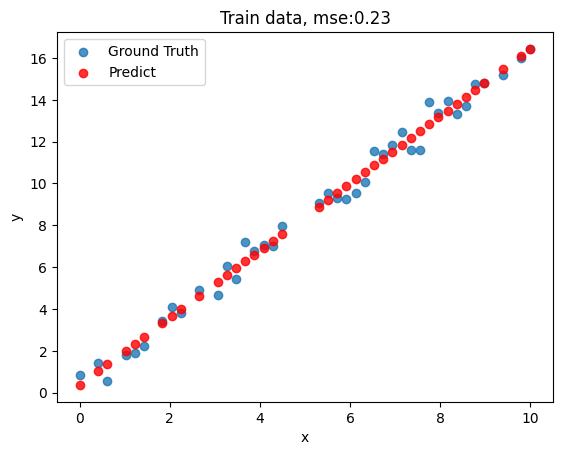

In [7]:
# ???????? MSE???????????
Y_train = regr.predict(X_train)
train_mse = mean_squared_error(y_train, Y_train)
print('Train MSE =', train_mse)

plt.title('Train data, mse:' + str(round(train_mse, 2)))
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(X_train.ravel(), y_train, alpha=0.8, label='Ground Truth')
plt.scatter(X_train.ravel(), Y_train, c='r', alpha=0.8, label='Predict')
plt.legend()


## 將訓練出來的函數預測測試集的X值
1. 使用剛剛訓練出來的模型進行測試資料集的資料預測*注意reshape<br>
使用X = 2.44897959，預測出來數值應該為 4.3025375<br>
所有測試集資料
$$\widehat{y}=xw+b=w_{1}x_{1}+b$$

In [8]:
# ????? X = 2.44897959 ?????
X_sample = np.array([[2.44897959]])
sample_prediction = regr.predict(X_sample)
print('Prediction for X = 2.44897959:', sample_prediction[0])


Prediction for X = 2.44897959: 4.302537504954737


In [9]:
# ??????????????????????
Y_test = regr.predict(X_test)
print('Model predictions:')
print(Y_test)

# ??? y_hat = xw + b ????
manual_Y_test = X_test * regr.coef_ + regr.intercept_
print('Formula predictions:')
print(manual_Y_test.ravel())


Model predictions:
[ 4.3025375   4.95828946  1.67952971  2.99103361 15.12244466  0.69590179
  8.56492518  8.23704919 15.7781966   7.90917322]
Formula predictions:
[ 4.3025375   4.95828946  1.67952971  2.99103361 15.12244466  0.69590179
  8.56492518  8.23704919 15.7781966   7.90917322]


2. 並計算出測試階段的MSE

In [10]:
# ???????? MSE
test_mse = mean_squared_error(y_test, Y_test)
print('Test MSE =', test_mse)


Test MSE = 0.41344072565862955


3. 畫出目標點(藍色)與預測點(紅色)的對應圖
![](images/LR_test.PNG)

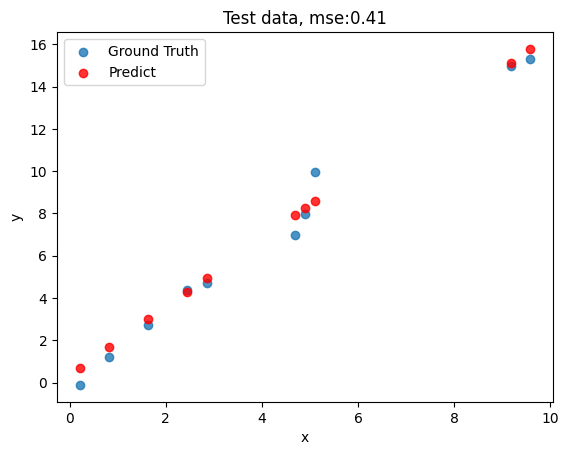

In [11]:
# ??????????????
title = 'Test data, mse:' + str(round(test_mse, 2))
plt.title(title)
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(X_test.ravel(), y_test, alpha=0.8, label='Ground Truth')
plt.scatter(X_test.ravel(), Y_test, c='r', alpha=0.8, label='Predict')
plt.legend()


In [12]:
# ????
print('w =', regr.coef_[0])
print('b =', regr.intercept_)
print('Train MSE =', train_mse)
print('Test MSE =', test_mse)


w = 1.6065922734317737
b = 0.36802581786862376
Train MSE = 0.2284495300761316
Test MSE = 0.41344072565862955
